# Assignment 2 - [Gandla Akshay Kumar]_[REDACTED]



# Preprocessing

In [37]:
# importing all necessary libraries

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [38]:
#loading the data

train_df=pd.read_csv("train_data.csv")
test_df=pd.read_csv("test_data.csv")

print(train_df.shape)
print(test_df.shape)

(614, 9)
(154, 9)


In [39]:
# printing the null values 
print("Sum of null values of Training Data")
print(train_df.isnull().sum())
print("\n")
print("Sum of null values of Testing Data")
print(test_df.isnull().sum())


Sum of null values of Training Data
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Sum of null values of Testing Data
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [40]:
# Splitting the data
X_train=train_df.drop("Outcome", axis=1)
y_train=train_df["Outcome"]
X_test=test_df.drop("Outcome", axis=1)
y_test=test_df["Outcome"]

# Standarad Scalling the data

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Dataloader
train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)


# Model Implementation

In [41]:
# implmenting presptorn using pytorch

class Perceptorn(nn.Module):
    def __init__(self, input_size=8,hidden1=32, hidden2=16):
        super(Perceptorn,self).__init__()
        self.network=nn.Sequential(
            nn.Linear(input_size,hidden1),
            nn.ReLU(),
            nn.Linear(hidden1,hidden2),
            nn.ReLU(),
            nn.Linear(hidden2,1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

model=Perceptorn()
criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
print(model)


Perceptorn(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [42]:
# Training the model
epochs = 100
loss_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_list.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [10/100], Loss: 0.4610
Epoch [20/100], Loss: 0.4324
Epoch [30/100], Loss: 0.4113
Epoch [40/100], Loss: 0.4191
Epoch [50/100], Loss: 0.4232
Epoch [60/100], Loss: 0.3911
Epoch [70/100], Loss: 0.4016
Epoch [80/100], Loss: 0.3799
Epoch [90/100], Loss: 0.3700
Epoch [100/100], Loss: 0.3669


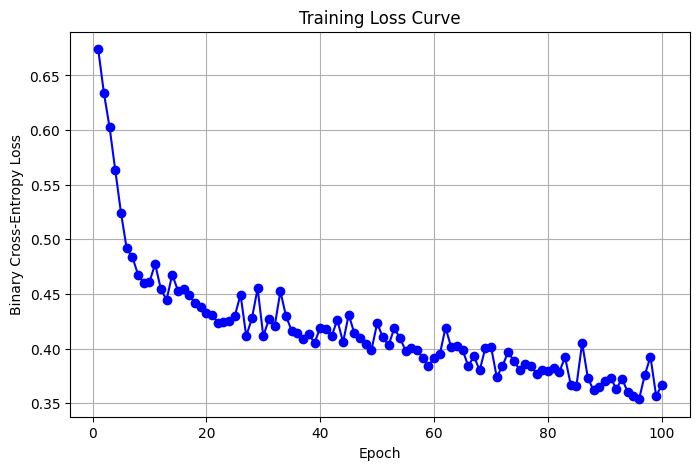

In [43]:
# Plotting the loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_list) + 1), loss_list, color='blue', marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()


In [44]:
# Evaluating the results

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).squeeze()
    y_pred_cls = (y_pred > 0.5).int()

print("Accuracy:", accuracy_score(y_test, y_pred_cls))
print(classification_report(y_test, y_pred_cls))
print(confusion_matrix(y_test, y_pred_cls))


Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.76      0.81      0.79        96
           1       0.65      0.59      0.62        58

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.72      0.73      0.72       154

[[78 18]
 [24 34]]


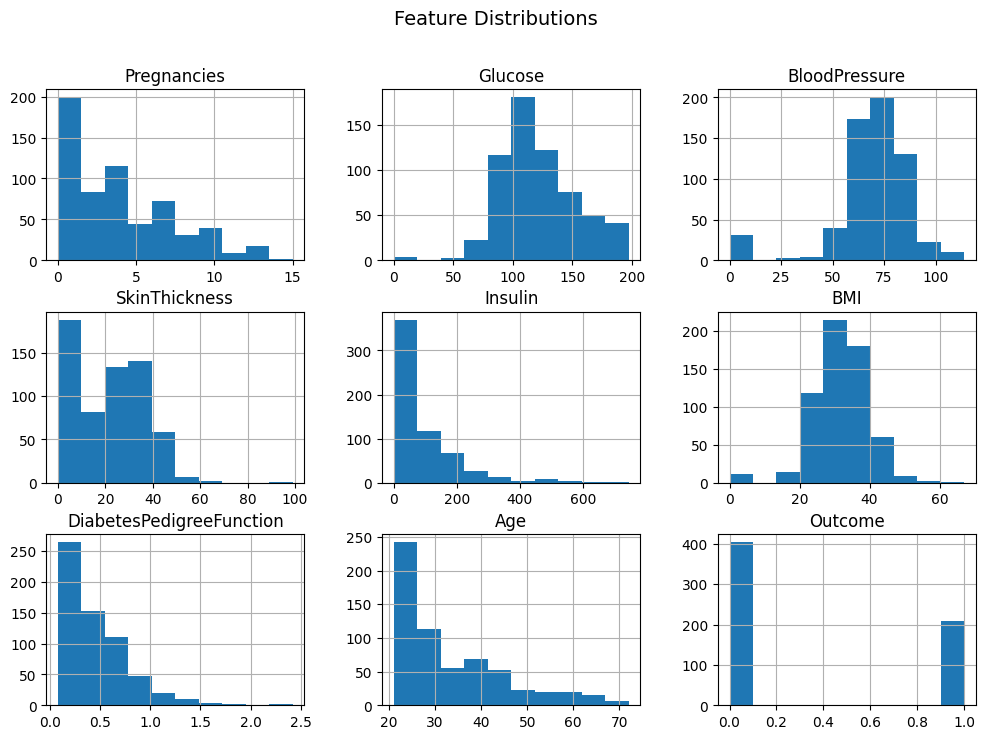

In [45]:

import seaborn as sns

# Distribution plots for each feature
train_df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()



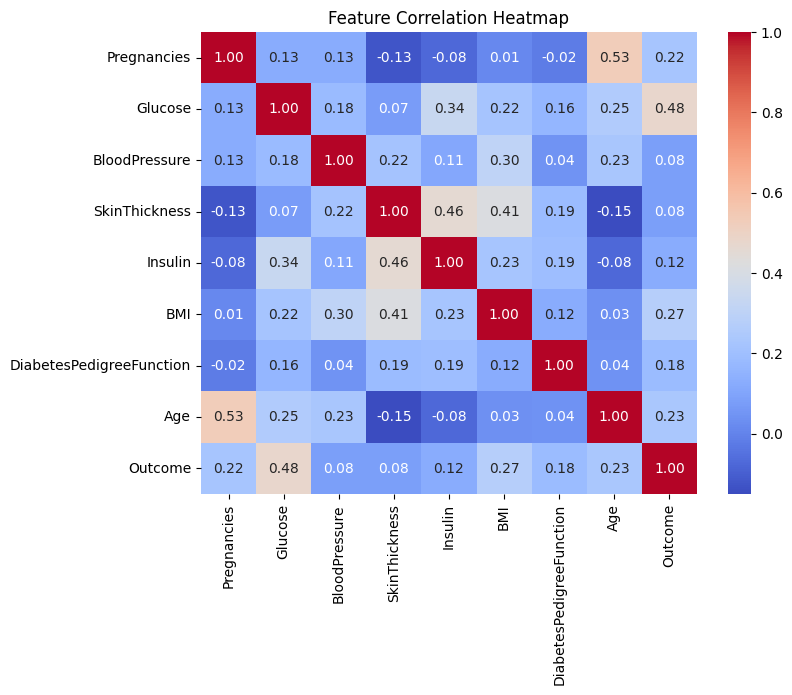

In [46]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(train_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


<local>\AppData\Local\Temp\ipykernel_26992\3338851221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=train_df, palette='pastel')


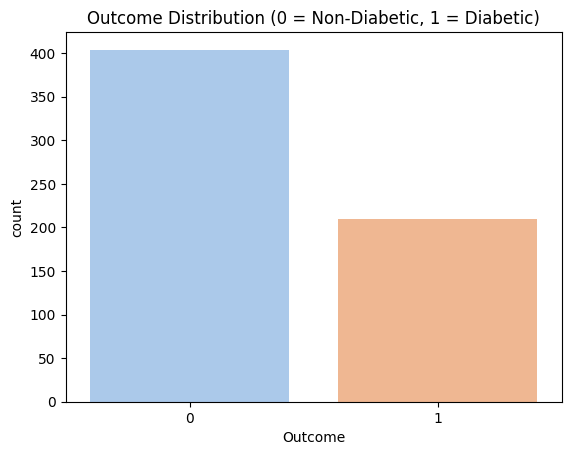

In [47]:
# Outcome balance
sns.countplot(x='Outcome', data=train_df, palette='pastel')
plt.title("Outcome Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

# Experiments

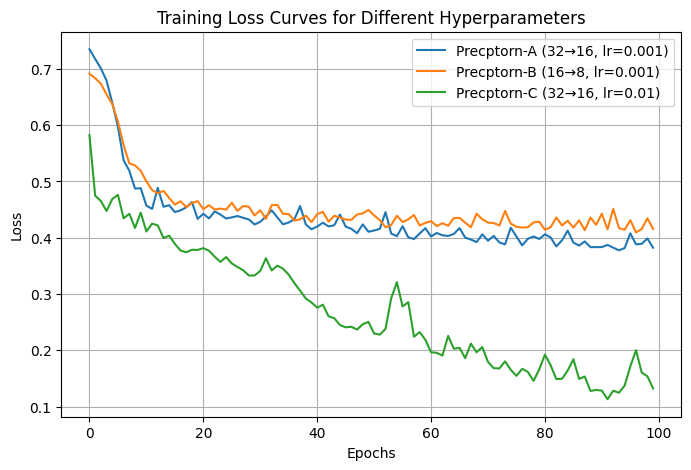

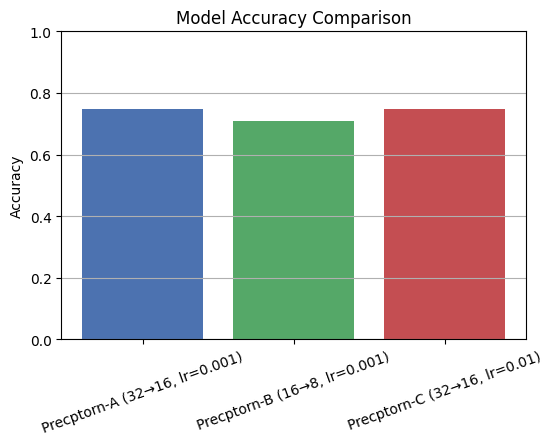

Precptorn-A (32→16, lr=0.001): Accuracy = 0.7468
Precptorn-B (16→8, lr=0.001): Accuracy = 0.7078
Precptorn-C (32→16, lr=0.01): Accuracy = 0.7468


In [48]:

# HYPERPARAMETER EXPERIMENTS

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Define a function to train and evaluate a model
def train_and_evaluate(hidden1, hidden2, lr, epochs=100):
    model = Perceptorn(hidden1=hidden1, hidden2=hidden2)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_list = []

    for epoch in range(epochs):
        total_loss = 0.0
        for xb, yb in train_loader:
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        loss_list.append(total_loss / len(train_loader))
    
    # Evaluate on test set
    with torch.no_grad():
        preds = model(X_test_tensor).squeeze()
        preds_cls = (preds > 0.5).int()
        acc = accuracy_score(y_test, preds_cls)
    
    return acc, loss_list

# Run experiments
experiments = {
    "Precptorn-A (32→16, lr=0.001)": (32, 16, 0.001),
    "Precptorn-B (16→8, lr=0.001)": (16, 8, 0.001),
    "Precptorn-C (32→16, lr=0.01)": (32, 16, 0.01)
}

results = {}
plt.figure(figsize=(8,5))

for name, (h1, h2, lr) in experiments.items():
    acc, loss_curve = train_and_evaluate(h1, h2, lr)
    results[name] = acc
    plt.plot(loss_curve, label=f"{name}")

plt.title("Training Loss Curves for Different Hyperparameters")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy Comparison Bar Chart
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values(), color=['#4c72b0','#55a868','#c44e52'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

# Print summary
for name, acc in results.items():
    print(f"{name}: Accuracy = {acc:.4f}")
